# IQC and IQC:AIL

## Imports

In [35]:
import qiskit
from qiskit_machine_learning.algorithms import VQC
from qiskit.circuit import QuantumCircuit
from qiskit.compiler import transpile

from qiskit_aer import Aer
from qiskit.visualization import plot_histogram, visualize_transition, plot_bloch_vector
from qiskit.circuit.library import UnitaryGate

import pennylane

import numpy as np
from scipy.linalg import expm as expMatrix
from sympy.physics.quantum.dagger import Dagger
import math

from sklearn.model_selection import StratifiedKFold,train_test_split
from sklearn.datasets import make_moons, make_blobs
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn import preprocessing
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, make_scorer, roc_auc_score

from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pdflatex

import pandas as pd

#C: 
from qiskit.quantum_info import Statevector,partial_trace, DensityMatrix


## Base de Dados

In [37]:
#Parâmetros
RANDOM_SEED = 42
N_SAMPLES = 400
N_FEATURES = 4
LEARNING_RATE = 0.01
RESPONSE_METHOD = "predict"
results = []

In [38]:
def generate_blobs(normalize_col=False, normalize_lin=False):
  X, y = make_blobs(n_samples=N_SAMPLES, n_features=N_FEATURES, centers=2, random_state=RANDOM_SEED,cluster_std=0.7)

  if normalize_col:
    scaler = MinMaxScaler()
    scaler.fit(X)
    X = scaler.transform(X)
    X = X - 1
  if normalize_lin:
    X = preprocessing.normalize(X,axis=1,norm='l2')


  return X, y

def generate_moons(normalize_col=False, normalize_lin=False):
  X, y = make_moons(n_samples=N_SAMPLES, n_features=N_FEATURES, random_state=RANDOM_SEED, noise=0.05)

  if normalize_col:
    scaler = MinMaxScaler()
    scaler.fit(X)
    X = scaler.transform(X)
    X = X - 1
  if normalize_lin:
    X = preprocessing.normalize(X,axis=1,norm='l2')


  return X, y

def generate_xor(normalize_col=False, normalize_lin=False):
  X, y = make_blobs(n_samples=N_SAMPLES, n_features=N_FEATURES, centers=[(0,0), (2,2), (0,2), (2,0)], random_state=RANDOM_SEED,cluster_std=0.2)
  y_xor = np.logical_xor(X[:, 0] > 0.5, X[:, 1] > 0.5).astype(int)

  if normalize_col:
    scaler = MinMaxScaler()
    scaler.fit(X)
    X = scaler.transform(X)
    X = X - 1
  if normalize_lin:
    X = preprocessing.normalize(X,axis=1,norm='l2')


  return X, y_xor

In [39]:
X,y=generate_blobs(normalize_col=True)

In [40]:
#Plotando os dados se N_features==2
if N_FEATURES==2:
    plt.figure(figsize=(8, 8))
    plt.title("Exemplo simples de base de dados", fontsize="small")
    plt.scatter(X[:, 0], X[:, 1], marker="o", s=25, c=y, edgecolor="k")
    plt.show()

In [41]:
len(X[0])

4

## Quantum Circuit

X[60]: [-0.79298003 -0.88710333 -0.87089833 -0.19788041] ; w: [1 1 1 1] 

sigmaE
[[-0.79298003  0.          0.          0.        ]
 [ 0.         -0.88710333  0.          0.        ]
 [ 0.          0.         -0.87089833  0.        ]
 [ 0.          0.          0.         -0.19788041]]


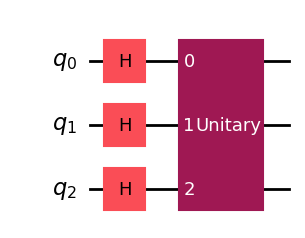

In [32]:
# Criando o circuito
N_atributos=len(X[0]) 
'''
Numero de atributos do vetor a ser classificado. Adicionamos mais 1 ao numero obtido antes(pois temos o qubit alvo)
'''
w=np.full(N_atributos,1)

#x=np.random.rand(N_atributos)
#w=np.random.rand(N_atributos)

N_qubits=math.ceil(np.log2(N_atributos)+1) #Nqubits do circuito

#Podíamos inicializar assim pra facilitar as contas
'''x=np.random.rand(2**N_atributos)
w=np.random.rand(2**N_atributos)'''

# IQC

qc = QuantumCircuit(N_qubits)
qc.h(0) # Inicializaçao do estado inicial. Poderia ser qualquer estado.
qc.h(range(1,N_qubits))



#Montando os sigmas

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

#Escolhendo uma linha aleatória de X para podermos debugar
lista=[i for i in range(len(X))]
j=np.random.choice(lista)

if np.log2(N_atributos) !=0:
    for k in range(2**(N_qubits-1) - N_atributos):
        X=np.append(X,0)
        w=np.append(w,0)
sigmaE=np.diag(X[j])*w.T

#Debugando
print(f'X[{j}]:', X[j], '; w:', w,'\n')
print('sigmaE')
print(sigmaE)
#Operador Unitário
U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

qubits=[i for i in range(N_qubits)]
# qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
qc.unitary(U,qubits)
qc.draw("mpl", filename='./mpl_original.pdf')

{'u3': 23, 'cx': 15}


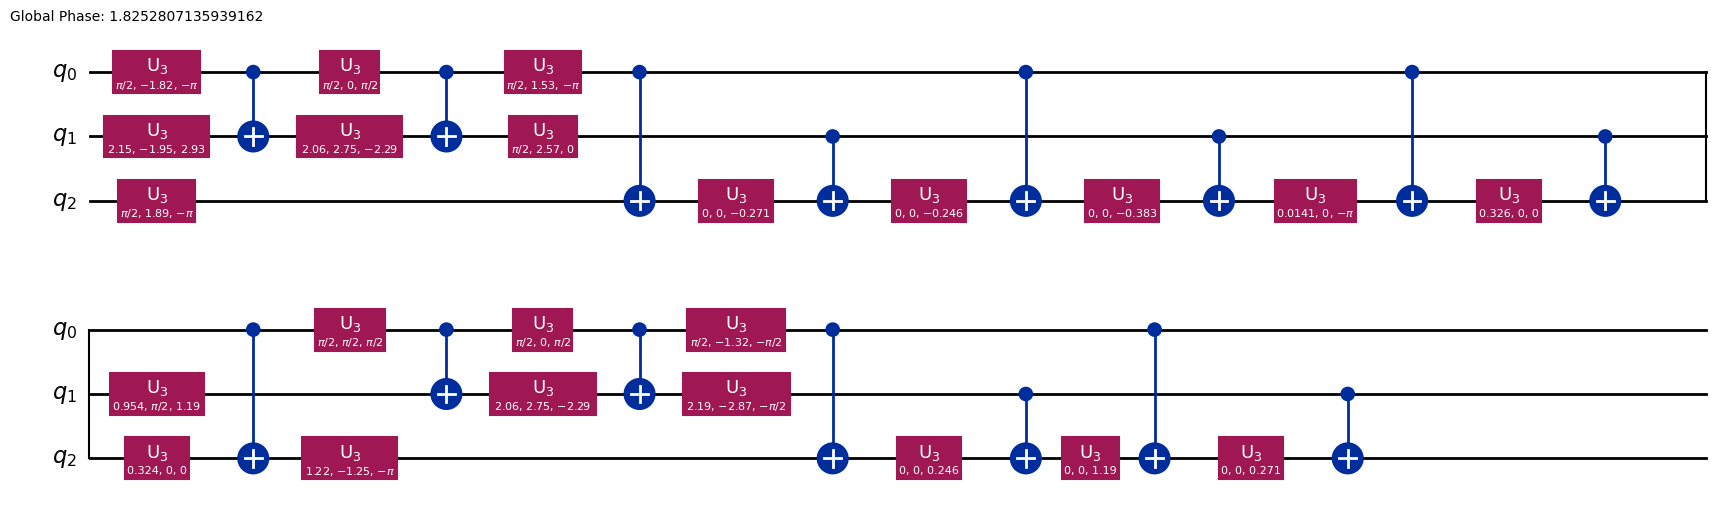

In [33]:
#qc.decompose().draw(output="mpl", style="clifford")
qc = transpile(qc, optimization_level=3, basis_gates=["u3", "cx"])
print(dict(qc.count_ops()))
qc.draw('mpl', filename='./mpl_transpile.pdf')
#qc.draw('latex_source',filename='./file.tex')
#!pdflatex file.tex


## Statevector e Matriz Densidade

Aqui vamos avaliar o estado depois da evolução 

### Statevector

In [95]:
#Estado completo
sv = Statevector(qc)
sv.draw("latex")

<IPython.core.display.Latex object>

In [96]:
def run_qasm_counts(circ, shots=1024):
  qc.measure_all()
  qasm_simulator = Aer.get_backend("qasm_simulator")
  job = qasm_simulator.run(qc, shots=shots)
  result = job.result()
  return result.get_counts()

counts = run_qasm_counts(qc)
counts

{'100': 54,
 '111': 179,
 '001': 203,
 '010': 221,
 '000': 169,
 '101': 55,
 '110': 59,
 '011': 84}

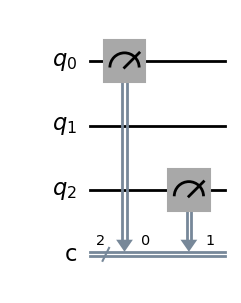

In [22]:
qc = QuantumCircuit(3,2)

#insira seu código aqui


qc.measure(0,0)
qc.measure(2,1)
qc.draw('mpl')

### Matriz Densidade

In [44]:
# Ao traçar fora o ambiente

rho_res = partial_trace(DensityMatrix.from_instruction(qc), qubits[1:]).data 
# C: para generalizar tem q substituir esse [] com o os qubits ancilla
print("Após o traco parcial")

print(rho_res)

Após o traco parcial
[[0.5       +9.10729825e-18j 0.38636076+9.76108062e-02j]
 [0.38636076-9.76108062e-02j 0.5       -7.58941521e-19j]]


### Toy Example

In [60]:
x=np.random.rand(2)
w=np.random.rand(2)

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z



sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

sigmaE=np.diag(x)*w.T

#Operador Unitário
#Hint=- hbar*g*np.kron(sigmaQ,sigmaE)
#U=expMatrix(-1j*Hint*(t/hbar))
U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))
print(len(U))
print (U@np.ones(len(U)))

4
[[1.12039016+3.18235537e-01j 1.15413187+6.08446142e-01j
  0.80215462-2.77555756e-17j 0.54568573+0.00000000e+00j]]


## IQC

In [3]:
def IQC(x,w):
  n = len(x)

  #from sympy.physics.matrices import msigma(indice)

  #Matrizes de Pauli e a matriz sigma-Q
  matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
  matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
  matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z



  sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

  sigmaE=np.diag(x)*w.T

  #Operador Unitário
  #Hint=- hbar*g*np.kron(sigmaQ,sigmaE)
  #U=expMatrix(-1j*Hint*(t/hbar))
  U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

  def get_p(psi):
    psi=np.matrix(psi)
    return psi*psi.getH()

  #Psis
  #Para os qubits
  psiQ=np.ones((2,1))
  psiQ=(psiQ/np.sqrt(2))

  psiE=np.ones((n,1))
  psiE=(psiE/np.sqrt(n))


  #Rhos
  rhoQ=get_p(psiQ)
  rhoE=get_p(psiE)
  rho_2_systems = np.array(U*(np.kron(rhoQ,rhoE))*Dagger(U))
  #p_cog_new = partial_trace(rho_2_systems, sys=2,dim=[2,n])
  rho_cog_new  = np.trace(rho_2_systems.reshape([2,n,2,n]), axis1=1, axis2=3)
  return rho_cog_new,sigmaE

## IQC:AIL

In [ ]:
def IQC_AIL(x,w):
  n = len(x)
  norma_x=np.linalg.norm(x)+1e-16 #To avoid zero division

  #Matrizes de Pauli e a matriz sigma-Q
  matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
  matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
  matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z



  sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

  sigmaE=np.diag(x)*w.T #No fim, é uma matriz composta apenas por pesos

  #Operador Unitário
  #Hint=- hbar*g*np.kron(sigmaQ,sigmaE)
  #U=expMatrix(-1j*Hint*(t/hbar))
  U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

  def get_p(psi):
    psi=np.matrix(psi)
    return psi*psi.getH()

  #Psis
  #Para os qubits
  psiQ=np.ones((2,1))
  psiQ=(psiQ/np.sqrt(2))

  psiE=np.ones((n,1))
  psiE=(psiE/np.sqrt(n))


  #Rhos
  rhoQ=get_p(psiQ)
  rhoE=get_p(psiE)
  rho_2_systems = np.array(U*(np.kron(rhoQ,rhoE))*Dagger(U))
  #p_cog_new = partial_trace(rho_2_systems, sys=2,dim=[2,n])
  rho_cog_new  = np.trace(rho_2_systems.reshape([2,n,2,n]), axis1=1, axis2=3)
  return rho_cog_new,sigmaE